## Pipeline générale Test 1 

In [2]:
import numpy as np
import cv2
from SCA import DFT2D
from scipy.stats import binom
import matplotlib.pyplot as plt

Import des fonctions qui ne nécéssitent pas de modifications:

In [ ]:
def CrossVal(NFA_rows, NFA_cols, beta=0.005):
    """
    beta : relative tolerance (marge)
    Hypothèse :  q1/N1 ≈ q2/N2 à ±β près

    Return : NFA validé et corrigé par le nombre de tests dans la marge
    """
    N1, N2 = NFA_rows.shape[0], NFA_cols.shape[0]
    ratios_rows = np.arange(N1) / (N1 - 1) if N1 > 1 else np.zeros(N1)
    ratios_cols = np.arange(N2) / (N2 - 1) if N2 > 1 else np.zeros(N2)
    
    NFA_valid = np.zeros(N1, dtype=np.float32)

    for d1 in range(N1):
        ratio_d1 = ratios_rows[d1]
        mask = np.abs(ratios_cols - ratio_d1) < beta
        num_tests = np.sum(mask) 
        
        if num_tests > 0:
            bestNFA2 = np.min(NFA_cols[mask])
            NFA2_corrected = bestNFA2 * num_tests
            NFA_valid[d1] = max(NFA_rows[d1], NFA2_corrected)
        else:
            NFA_valid[d1] = np.max(NFA_cols) * N2 

    return NFA_valid


def ranktransform(x):
    """
    Rank transform of the image input x
    Computes the rank of the intensity of each pixel x in its 7x7 neighborhood
    """
    image = np.array(x, dtype=np.float32)

    # Traitement des problèmes de bord
    pad = 3 # 7 // 2
    padded = np.pad(image, pad, mode='reflect')

    H, W = image.shape
    rtImage = np.zeros((H, W), dtype=np.float32)
    for x in range(-pad, pad + 1):
        for y in range(-pad, pad + 1):
            if y == 0 and x == 0:  #pixel central
                continue
            neighbor = padded[pad + y: pad + y + H, pad + x: pad + x + W]
            rtImage += (neighbor < image).astype(np.float32)
 
    return rtImage


Transformation en fonction de NFA

In [4]:
def correlation(Pi, Qi):
    """
    Calcule la corrélation spectrale entre deux patchs Pi et Qi
    """
    Pi = Pi - np.mean(Pi)
    Qi = Qi - np.mean(Qi)
    num = np.abs(np.dot(Pi, np.conj(Qi)))
    den = np.linalg.norm(Pi) * np.linalg.norm(Qi) + 1e-8
    return num / den

def compute_NFA_axis(S, axis='rows', R=1, DMAX=500, PATCH_SIZE=8):
    """
    Calcule le vecteur NFA pour un axe donné ('rows' ou 'cols') à partir du spectre S.
    """
    if axis == 'cols':
        S_axis = S.T
    else:
        S_axis = S

    N0, N1 = S_axis.shape

    X_min = R + 1
    X_max = min(DMAX, N1 - R - 1)
    C = N1 - 2 * R - 1
    step = PATCH_SIZE

    k = np.zeros(X_max + 1)
    all_is_max = []
    nb_patch = 0

    for y in range(0, N0 - PATCH_SIZE, step):
        for x in range(0, N1 - (X_max + PATCH_SIZE + R + 1), step):
            nb_patch += 1
            Pi = S_axis[y:y + PATCH_SIZE, x:x + PATCH_SIZE].flatten()
            
            rho = np.zeros(X_max + R + 1 - (X_min - R))
            
            for d in range(X_min - R, X_max + R + 1):
                Qi = S_axis[y:y + PATCH_SIZE, x + d:x + d + PATCH_SIZE].flatten()
                rho[d - (X_min - R)] = correlation(Pi, Qi)
                
            for d in range(X_min, X_max + 1):
                i = d - (X_min - R)
                Nr = rho[i - R: i + R + 1]
                is_max = int(rho[i] == np.max(Nr))
                all_is_max.append(is_max)
                k[d] += is_max

    p = np.mean(all_is_max) if len(all_is_max) > 0 else 1.0 / (2 * R + 1)

    NFA = np.ones(X_max + 1, dtype=np.float32) * 1e10 
    
    for d in range(X_min, X_max + 1):
        proba = binom.sf(int(k[d]) - 1, nb_patch, p)
        NFA[d] = C * proba

    return NFA

In [ ]:
def Pipeline_Detection(image_path, beta=0.005, R=1, DMAX=500, PATCH_SIZE=8):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # image en niveaux de gris
    if img is None:
        raise ValueError("Impossible de charger l'image.")
    img = img.astype(np.float32)

    # Rank transform pour extraire le résidu
    img_residu = ranktransform(img)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_residu, cmap='gray')
    axes[0].set_title("Image Résiduelle (Rank Transform)")
    axes[0].axis('off')

    # Passage dans le domaine fréquentiel 2D
    S = DFT2D(img_residu)

    S_shift = np.fft.fftshift(S)
    axes[1].imshow(np.log(1 + np.abs(S_shift)), cmap='inferno')
    axes[1].set_title("Spectre SCA du Résidu (Échelle Log)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Recherche des corrélations spectrales (SCA) + NFA sur les lignes
    NFA_rows = compute_NFA_axis(S, axis='rows', R=R, DMAX=DMAX, PATCH_SIZE=PATCH_SIZE)

    # Recherche des corrélations spectrales (SCA) + NFA sur les colonnes
    NFA_cols = compute_NFA_axis(S, axis='cols', R=R, DMAX=DMAX, PATCH_SIZE=PATCH_SIZE)

    # Validation croisée (Cross-Validation)
    print("Validation croisée des résultats...")
    NFA_valid = CrossVal(NFA_rows, NFA_cols, beta=beta)

    # Décision
    EPSILON = 1.0
    detections = np.where(NFA_valid < EPSILON)[0]

    plt.figure(figsize=(12, 4))
    v_display = np.copy(NFA_valid); v_display[v_display > 1e4] = 1e4
    plt.plot(np.log10(v_display + 1e-20), label="log10(NFA Validé)", color='blue', linewidth=2)
    plt.axhline(y=np.log10(EPSILON), color='red', linestyle='--', label=f'Seuil Critique Epsilon ({EPSILON})')
    
    # Si on a des détections, on les marque par des points rouges sur le graphique
    if len(detections) > 0:
        plt.scatter(detections, np.log10(NFA_valid[detections] + 1e-20), 
                    color='red', zorder=5, label=f"Detections: d={detections}")
        print(f"\n Rééchantillonnage détecté aux distances : {detections}")
    else:
        print("\nAucune trace de rééchantillonnage validée globalement.")
        
    plt.title(" Résultat Final : NFA Validé après Cross-Validation")
    plt.xlabel("Distance d (pixels)")
    plt.ylabel("log10(NFA)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()
    
    return NFA_valid, detections

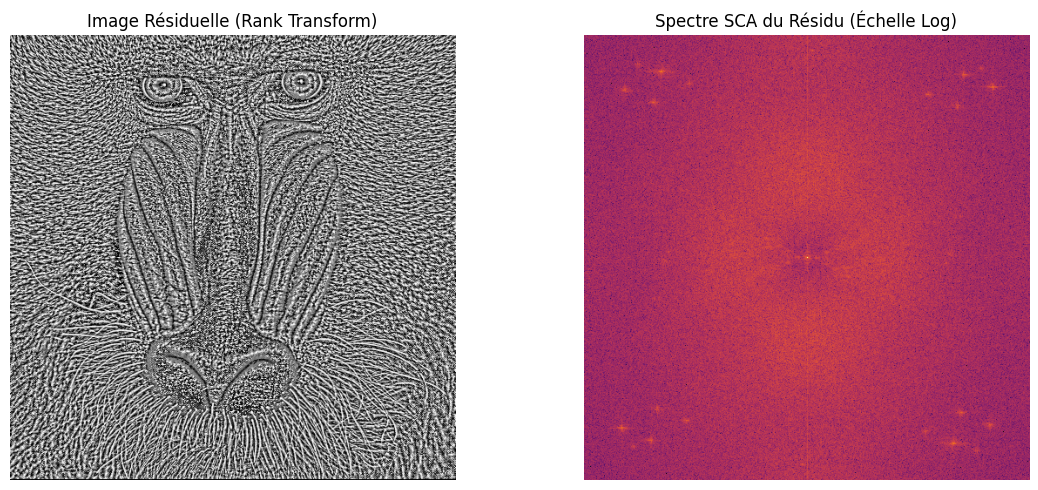

Validation croisée des résultats...

Aucune trace de rééchantillonnage validée globalement.


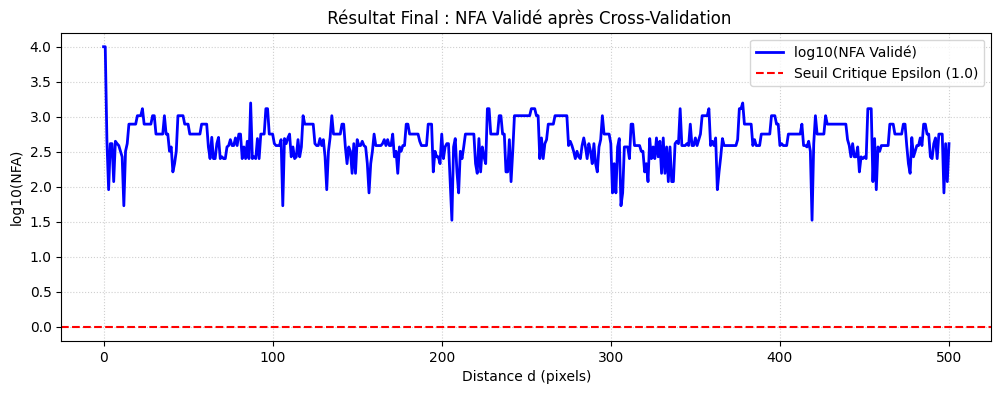

In [6]:
NFA_valid, detections =Pipeline_Detection("./IMG_InPut/babbon.png")

Avec le babbon : aucun pic détecté -> pas rééchantillonné 

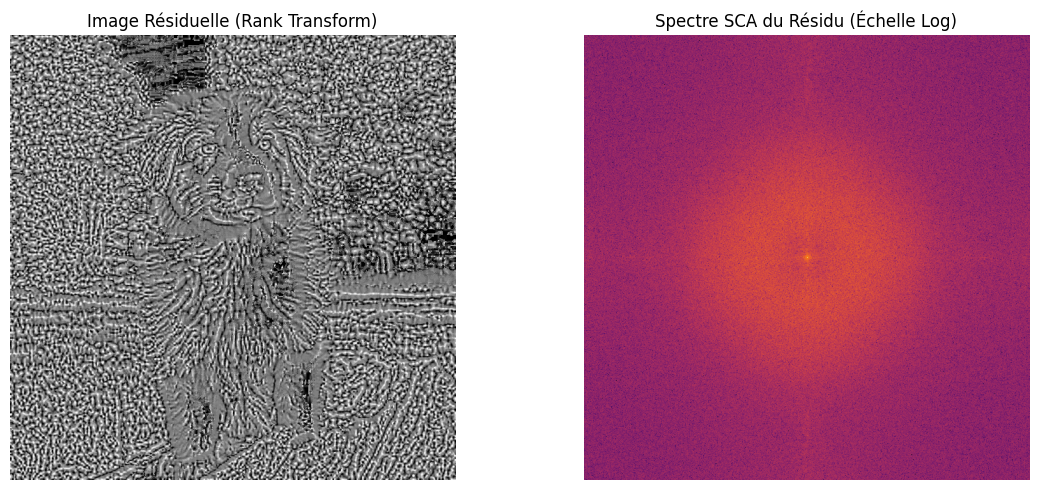

Validation croisée des résultats...

 Rééchantillonnage détecté aux distances : [160 224 240 304 320 384 400]


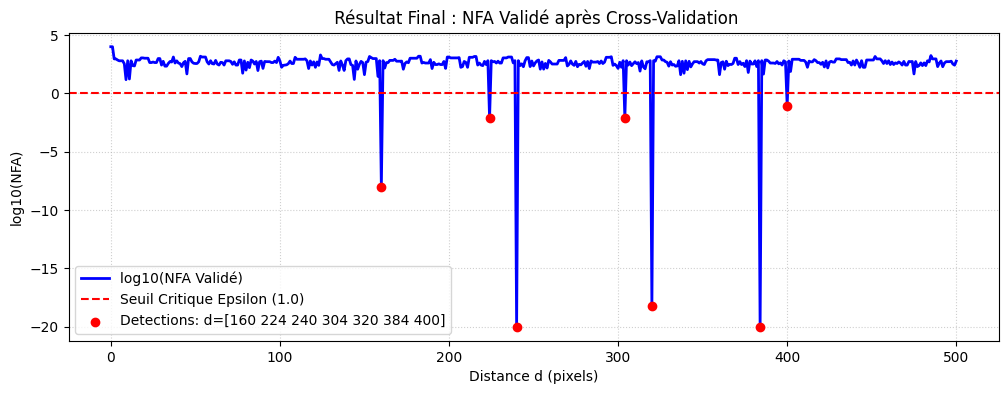

In [7]:
NFA_valid, detections =Pipeline_Detection("./IMG_InPut/Pashmina_rezised.jpg")

L'algo détecte bien que l'image a été resize

## Tests plusieurs facteurs différents


Traitement de l'image : ./IMG_InPut/pashmina.jpg


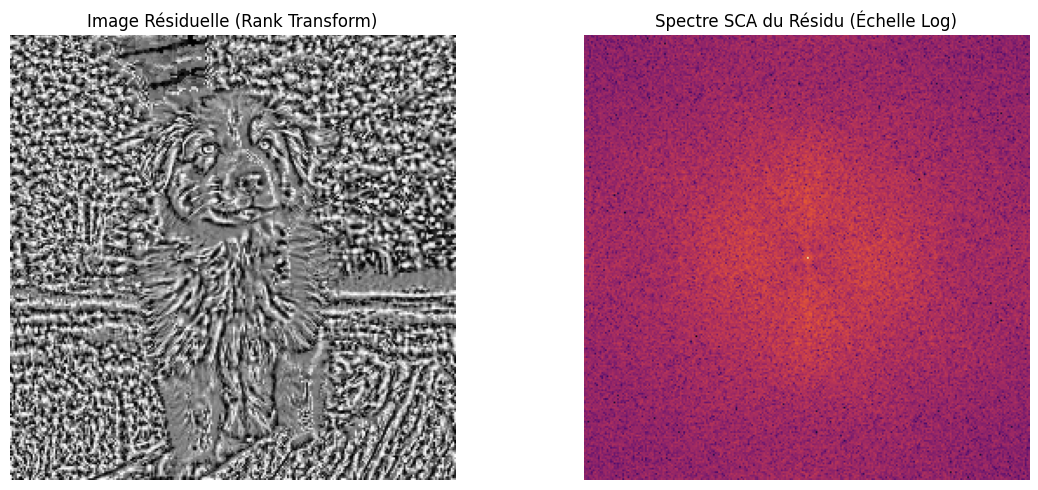

Validation croisée des résultats...

Aucune trace de rééchantillonnage validée globalement.


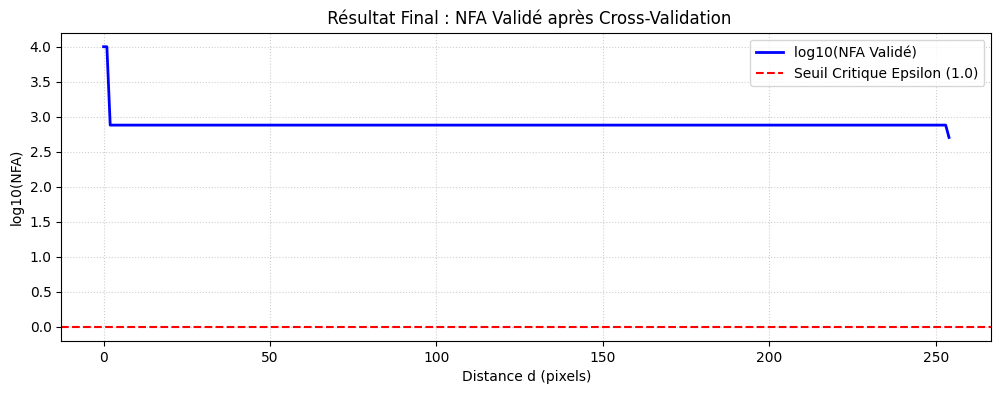


Traitement de l'image : ./IMG_InPut/pashmina :2.jpg


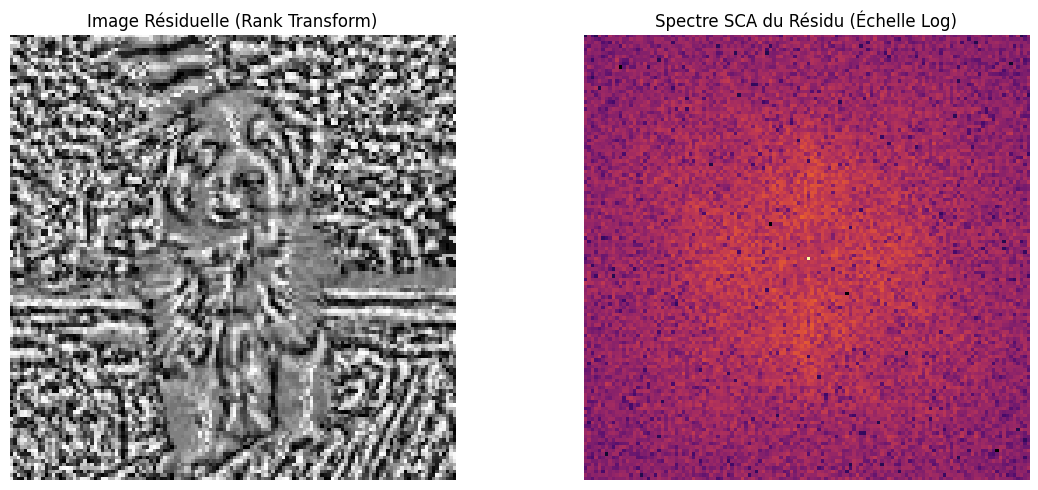

Validation croisée des résultats...

Aucune trace de rééchantillonnage validée globalement.


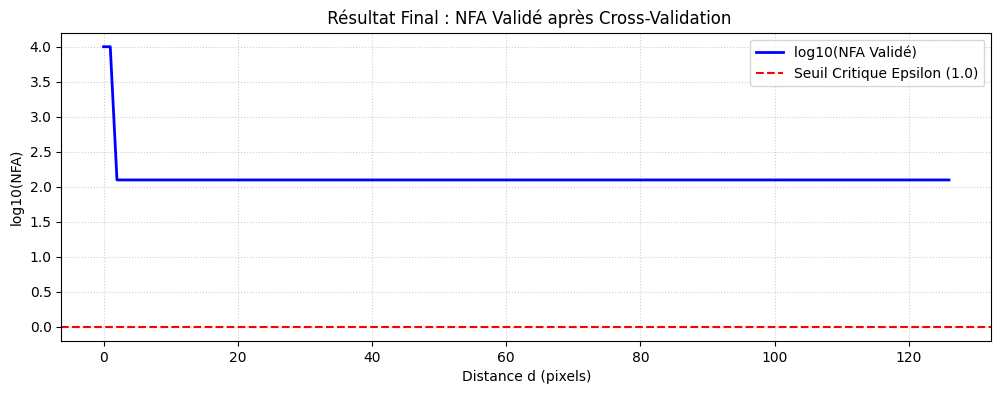


Traitement de l'image : ./IMG_InPut/pashmina x0,3.jpg


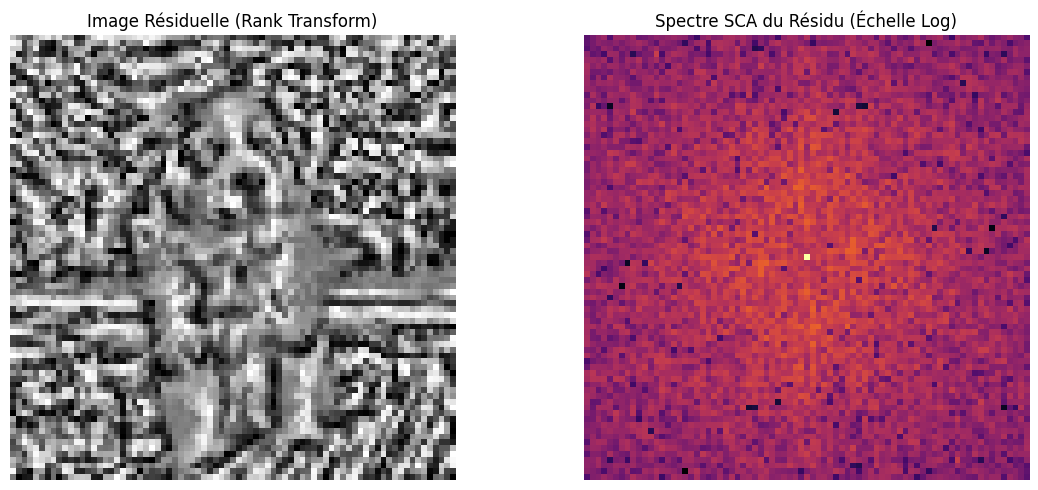

Validation croisée des résultats...

Aucune trace de rééchantillonnage validée globalement.


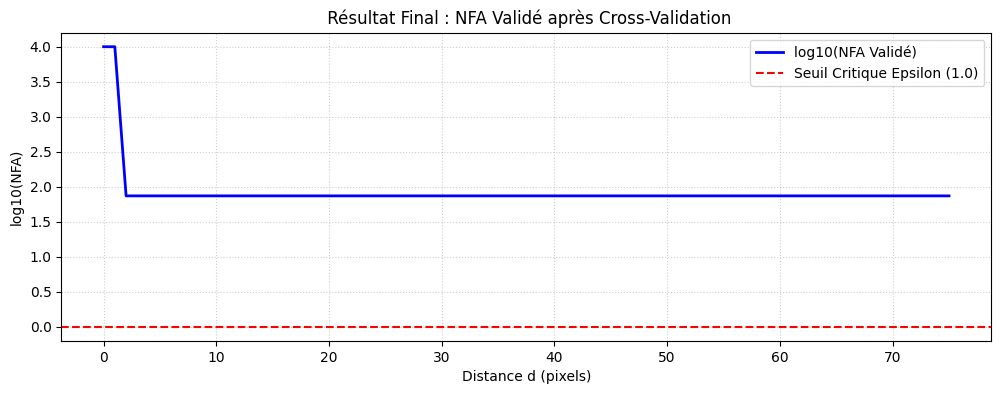


Traitement de l'image : ./IMG_InPut/pashmina x1,7.jpg


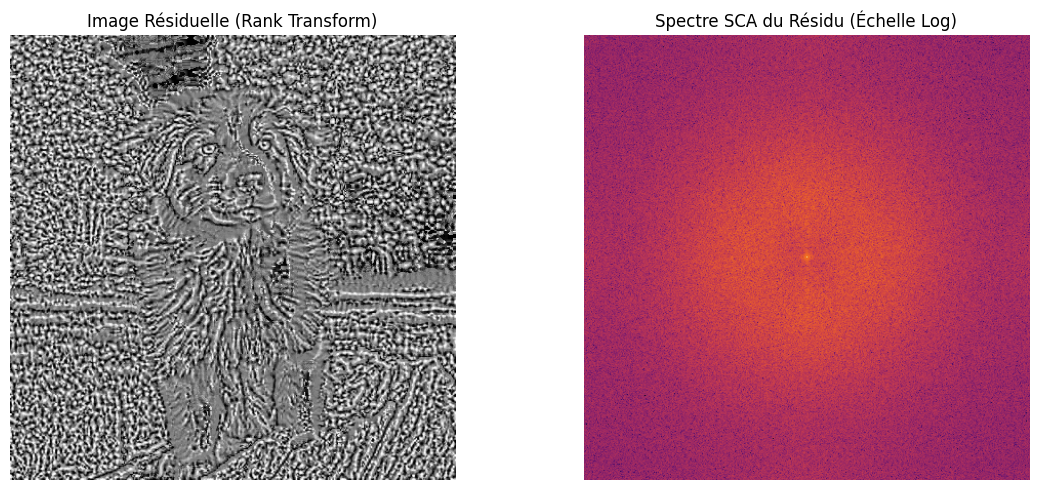

Validation croisée des résultats...

Aucune trace de rééchantillonnage validée globalement.


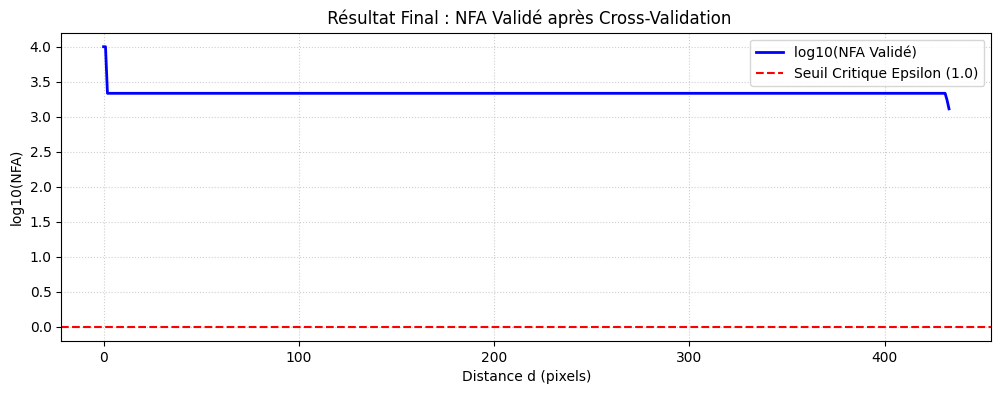


Traitement de l'image : ./IMG_InPut/pashmina X4 puis :4.jpg


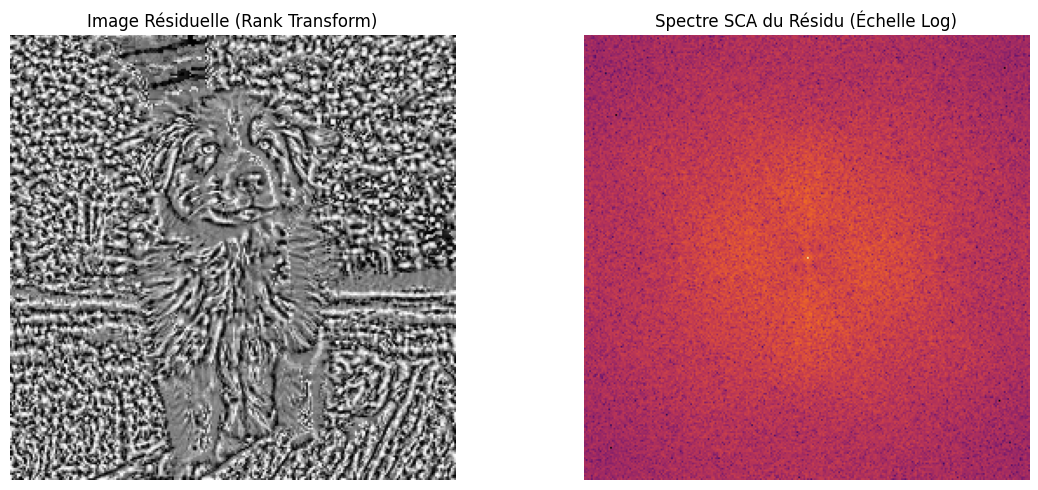

Validation croisée des résultats...

Aucune trace de rééchantillonnage validée globalement.


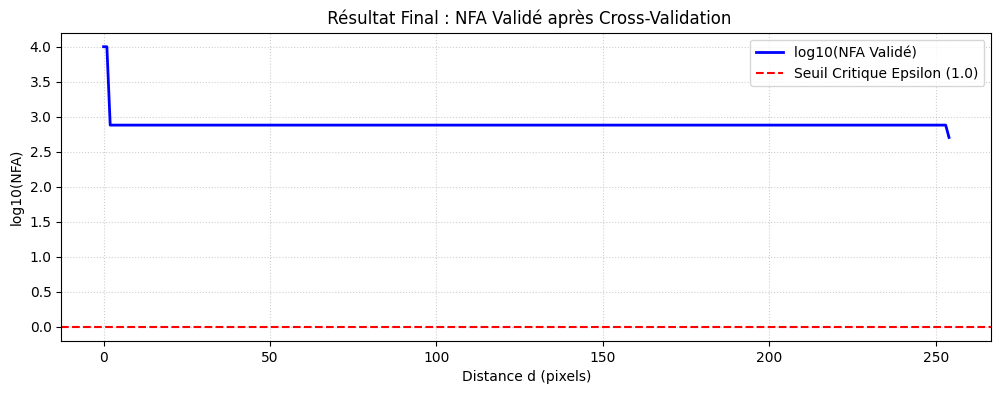


Traitement de l'image : ./IMG_InPut/pashminax4.jpg


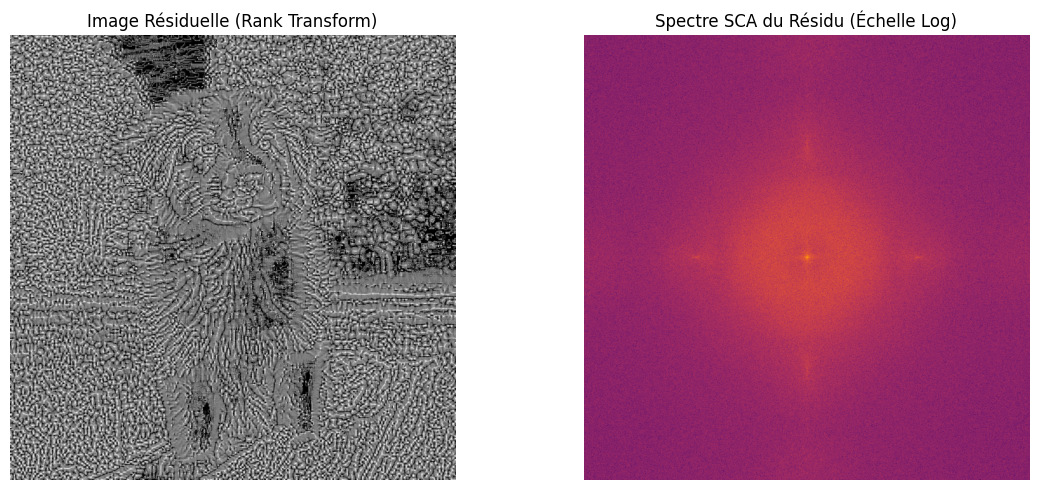

Validation croisée des résultats...

 Rééchantillonnage détecté aux distances : [128 256 384]


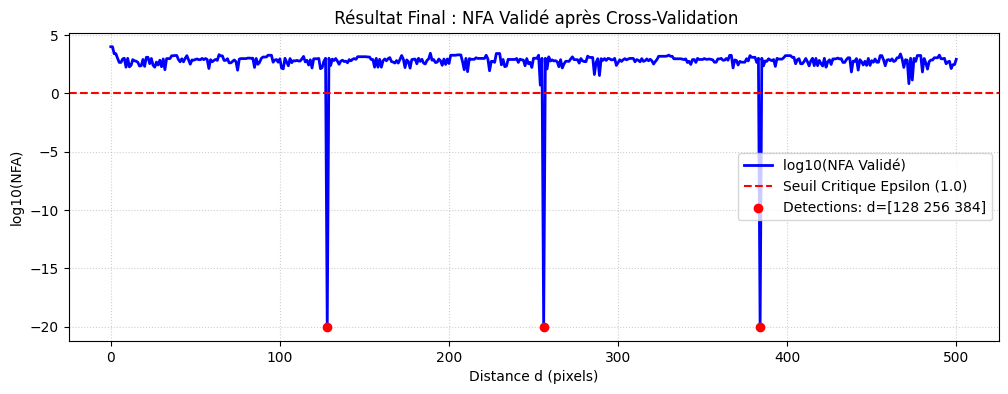


Traitement de l'image : ./IMG_InPut/pashminax8.jpg


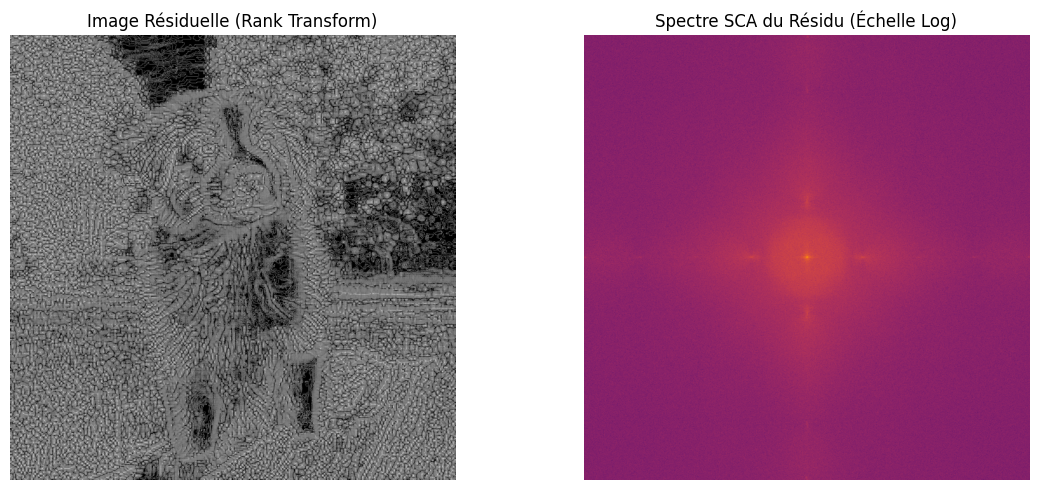

Validation croisée des résultats...

 Rééchantillonnage détecté aux distances : [  2   6 256]


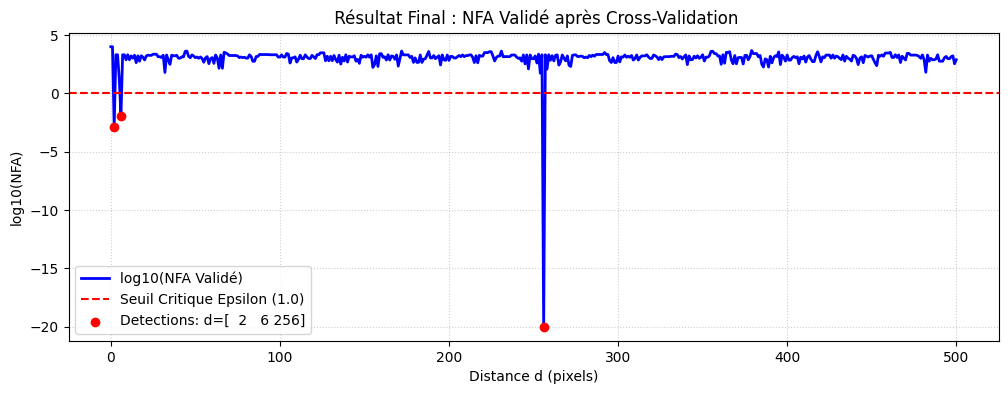

In [13]:
images = [
    "./IMG_InPut/pashmina.jpg",
    "./IMG_InPut/pashmina :2.jpg",
    "./IMG_InPut/pashmina x0,3.jpg",
    "./IMG_InPut/pashmina x1,7.jpg",
    "./IMG_InPut/pashmina X4 puis :4.jpg",
    "./IMG_InPut/pashminax4.jpg",
    "./IMG_InPut/pashminax8.jpg"
]

for image_path in images:
    print(f"\nTraitement de l'image : {image_path}")

    try:
        NFA_valid, detections = Pipeline_Detection(image_path)
    except Exception as e:
        print(f"Erreur : {e}")

La pipeline fonctionne bien pour les forts agrandissements à facteur entier (×4, ×8), mais échoue sur les réductions, les facteurs décimaux, et les doubles rééchantillonnages. Ce sont des directions d'amélioration naturelles.


1. pashmina.jpg — Image originale

Résultat : Aucune détection 

Le NFA reste au-dessus du seuil sur toute la plage. C'est le comportement attendu : pas de rééchantillonnage, pas de corrélation périodique dans le spectre. Le spectre SCA est uniforme et bruité, ce qui confirme l'absence d'artefact.

2. pashmina :2.jpg — Réduit par 2

Résultat : Aucune détection (manqué)

Explication : 

- L'image est petite après réduction → peu de patchs → statistiques fragiles
- X_min = R+1 = 2 : la distance d=2 est à la toute limite inférieure de ta plage de recherche, ce qui peut faire rater le pic si la corrélation est légèrement décalée
Le NFA chute bien (courbe descendante visible) mais ne passe pas sous EPSILON=1.0, ce qui suggère un signal réel mais trop faible statistiquement


". pashmina x0,3.jpg — Réduit par 0,3

Résultat : Aucune détection 

L'image est très petite (facteur < 1). La plage de distances explorée est donc très réduite (axe X va jusqu'à ~75 pixels seulement). Le facteur 0,3 est non entier, donc les corrélations sont étalées sur plusieurs d sans pic dominant. C'est une limite structurelle : ta méthode cherche des pics à des distances entières, incompatible avec des facteurs décimaux.

4. pashmina x1,7.jpg — Agrandi par 1,7

Résultat : Aucune détection (attendu difficile)

Même problème que ×0,3 : le facteur 1,7 est irrationnel. La corrélation théorique se produirait à d ≈ 1/(1 - 1/1.7) ≈ une valeur non entière. L'énergie est donc dispersée sur plusieurs d voisins. La courbe est très plate et haute (~3,5 en log10), signe qu'il n'y a aucun pic statistiquement significatif sur toute la plage. Ce cas confirme la limite fondamentale de l'approche à distances entières.

5. pashmina X4 puis :4.jpg — Agrandi ×4 puis réduit ÷

Résultat : Aucune détection (partiellement attendu)

Le double rééchantillonnage successif brouille les traces. Un ×4 puis ÷4 ne revient pas exactement à l'identité : il y a une perte de qualité et des artefacts d'interpolation, mais ils ne présentent pas de structure périodique simple. Le spectre SCA est propre et uniforme, très similaire à l'image originale. La pipeline ne peut pas distinguer cet artefact dégradé d'une image native.

6. pashminax4.jpg — Agrandi par 4

Résultat : Détection à d = [128, 256, 384] 

Excellente détection ! Les pics à 128, 256 et 384 sont exactement les multiples de 128 — et non de 4 directement. Cela s'explique par la taille de l'image agrandie : si la largeur est par exemple 512 pixels, la période de rééchantillonnage crée des corrélations à W/4 = 128. Les trois pics à 128, 256 (=2×128) et 384 (=3×128) sont les harmoniques de cette fréquence fondamentale. C'est un résultat très cohérent et robuste — le NFA descend à des valeurs extrêmement basses (log10 ≈ −20).

7. pashminax8.jpg — Agrandi par 8

Résultat : Détection à d = [2, 6, 256]  (partiel)

Deux pics sont cohérents avec un ×8 (notamment d=256 qui peut correspondre à une harmonique), mais d=2 et d=6 sont suspects — ce sont probablement des faux positifs résiduels non filtrés par la cross-validation. Le pic dominant attendu pour ×8 serait à une distance liée à la taille de l'image divisée par 8. La détection est réelle mais les distances détectées méritent une interprétation plus fine selon la résolution de l'image.